# Fase 4 · Modelo final y prueba reservada

**Universidad:** UNIFRANZ — **Materia:** Minería de Datos.

**Integrantes:** Milenka Melody Chuquimia Osco; Edson Teddy Tito Chuquimia; Carlos Daniel Valverde Mendoza; Alvaro Luis Carlos del Carpio Blanco; Marcelo Josue Escobar Chipana.

Clasificación retrospectiva de registros completos. La población corresponde a los estudiantes universitarios representados en el CSV. La etiqueta no es un diagnóstico clínico. No se demuestra causalidad, representatividad institucional ni detección anticipada. El KPI descriptivo es 24,974 % de etiquetas High; no mide calidad predictiva.


## Condición de entrada y procedimiento congelado

Este notebook requiere selección válida. Crea un pipeline nuevo con hiperparámetros ganadores y 14 predictores, aprende preprocesamiento y clasificador con 42.500 registros y después carga prueba. Las ejecuciones posteriores verifican y muestran resultados guardados. No se seleccionan otros modelos ni parámetros tras prueba.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "wrangler/03_PREPARACION_DATOS/artefactos/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "wrangler/04_MODELADO"))
from eduanalytics_modelado import core
from eduanalytics_modelado.academico import texto, metricas, matrices, presentar_modelo, presentar_comparacion
import pandas as pd
from IPython.display import display
entradas = core.verificar_entradas()
print("Python:", core.versiones()["Python"], "scikit-learn:", core.versiones()["scikit-learn"])
print("CSV:", entradas["input"]["path"], "SHA-256:", entradas["input"]["sha256"])
directory = core.experimento_actual()
selection = core._seleccion_valida(directory)
display(selection["final_training"])
final = core.finalizar(directory)

Python: 3.10.6 scikit-learn: 1.7.2
CSV: dataset/ai_student_impact_dataset (1).csv SHA-256: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5


{'new_unfitted_pipeline': True,
 'no_retuning_after_test': True,
 'partitions_in_order': ['train', 'validation'],
 'rows': 42500,
 'test_rows': 7500}

## Resultados finales reales

El modelo final se entrenó con más registros que los candidatos comparados en validación. Prueba evalúa el modelo congelado, no sirve para escoger candidatos. Las probabilidades estiman etiquetas y no representan calibración clínica.

,f1,precision,precision_undefined,recall,support
Low,0.521313,0.546959,False,0.497964,2456
Medium,0.542586,0.486845,False,0.61274,3171
High,0.539097,0.666143,False,0.45275,1873


Macro F1 = **0.534332**, Accuracy = **0.535200**. High: Precision **0.666143** y Recall **0.452750**. El soporte representa registros de cada etiqueta.

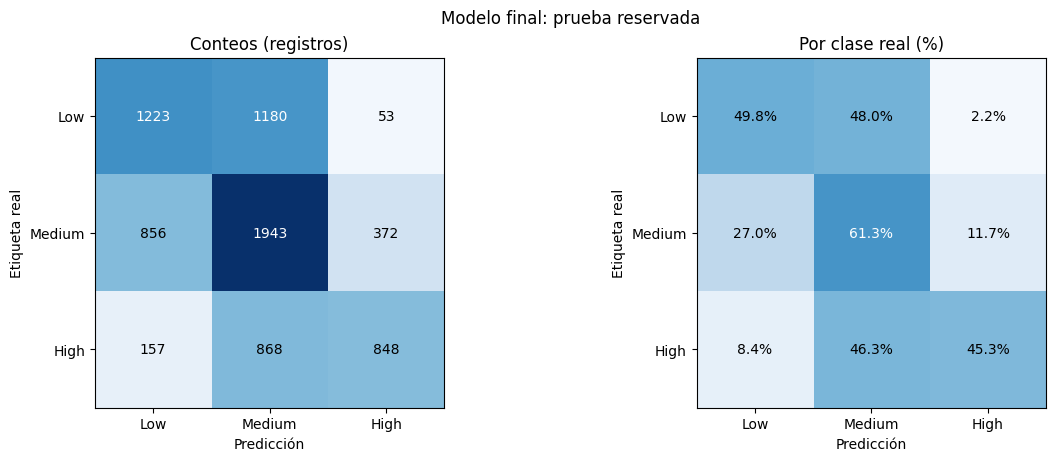

High→Low: **157**; High→Medium: **868**. Low→High: **53**; Medium→High: **372**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

{'final_fit_seconds': 0.21097739995457232,
 'finished_utc': '2026-10-09T20:07:00.358867+00:00',
 'test_inference_seconds': 0.017215500120073557}

,_row_id,Student_ID,actual,predicted,prob_Low,prob_Medium,prob_High
0,15220,115221,High,Medium,0.303244,0.505723,0.191033
1,45578,145579,Medium,Medium,0.300751,0.491163,0.208086
2,3573,103574,Low,Low,0.490707,0.426136,0.083157
3,25998,125999,Medium,Medium,0.310125,0.497811,0.192063
4,14627,114628,Low,Low,0.490876,0.414377,0.094747


{'classes': ['Low', 'Medium', 'High'],
 'estimator_classes': ['High', 'Low', 'Medium'],
 'experiment_id': '3db94eb69df3c875',
 'hyperparameters': {'clasificador__C': 100,
  'clasificador__class_weight': None},
 'model': 'logistica',
 'predictors': ['Major_Category',
  'Year_of_Study',
  'Pre_Semester_GPA',
  'Weekly_GenAI_Hours',
  'Primary_Use_Case',
  'Prompt_Engineering_Skill',
  'Tool_Diversity',
  'Paid_Subscription',
  'Traditional_Study_Hours',
  'Perceived_AI_Dependency',
  'Institutional_Policy',
  'Anxiety_Level_During_Exams',
  'Post_Semester_GPA',
  'Skill_Retention_Score'],
 'scenario': 'principal',
 'selection_sha256': '1cbf4773cd350fe63d7e88a2864c49615364d962dcabf8a866f9bbf5a4f8be66',
 'test': {'accuracy': 0.5352,
  'by_class': {'High': {'f1': 0.5390972663699937,
    'precision': 0.6661429693637078,
    'precision_undefined': False,
    'recall': 0.45274959957287775,
    'support': 1873},
   'Low': {'f1': 0.5213128729752771,
    'precision': 0.5469588550983899,
    'prec

In [2]:
metricas(final, "test")
matrices(final["test"], directory, "final_prueba_confusion", "Modelo final: prueba reservada")
display(core.leer(directory / "final/ejecucion.json"))
pred = pd.read_csv(directory / "final/predicciones_prueba.csv", sep=";")
display(pred.head())
display(final)

## Persistencia y comprobación independiente

El archivo joblib contiene el pipeline completo. El verificador inicia un proceso nuevo, carga el modelo y reproduce todas las etiquetas y probabilidades de prueba. Los hashes y controles constan en la evidencia generada.

In [3]:
from eduanalytics_modelado.verificacion import verificar
evidencia = verificar(directory)
display(evidencia)
from eduanalytics_modelado.academico import generar_informe
print(generar_informe(directory).relative_to(ROOT))

{'experiment_id': '3db94eb69df3c875',
 'input_hashes': 'PASS',
 'partitions': [{'partition': 'train',
   'rows': 35000,
   'Low': 11458,
   'Medium': 14801,
   'High': 8741},
  {'partition': 'validation',
   'rows': 7500,
   'Low': 2455,
   'Medium': 3172,
   'High': 1873},
  {'partition': 'test',
   'rows': 7500,
   'Low': 2456,
   'Medium': 3171,
   'High': 1873}],
 'membership_order_and_coverage': 'EXACT',
 'reconstruction': 'EXACT',
 'row_and_student_overlap': 0,
 'shared_folds': 'PASS',
 'full_protocol_fits': 393,
 'results_receipts': 'PASS',
 'selection_before_test': 'PASS',
 'frozen_selection': 'PASS',
 'directed_tests': {'fresh_instances': 'PASS',
  'fold_only_scaler_and_categories': 'PASS',
  'unknown_categories': 'PASS',
  'boolean_conversion': 'PASS',
  'metrics_order_and_orientation': 'PASS',
  'test_guard': 'PASS',
  'corrupt_artifact_rejected': 'PASS',
  'changed_protocol_rejected': 'PASS',
  'scenarios': [14, 12]},
 'independent_load': {'new_process': True,
  'prediction

wrangler\04_MODELADO\INFORME_FASE4_MODELADO.md


## Límites y Fase 5 pendiente

Fase 2 exploró el CSV completo; prueba es una partición interna reservada, no una cohorte externa nunca inspeccionada. Un alto rendimiento puede reflejar reglas desconocidas de la etiqueta. No demuestra causalidad, utilidad clínica, origen sintético ni detección anticipada. No demuestra reducir el KPI de etiquetas High. La evaluación de negocio y decisiones institucionales corresponden a Fase 5.